In [361]:
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view # for convolutions
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from IPython.display import display

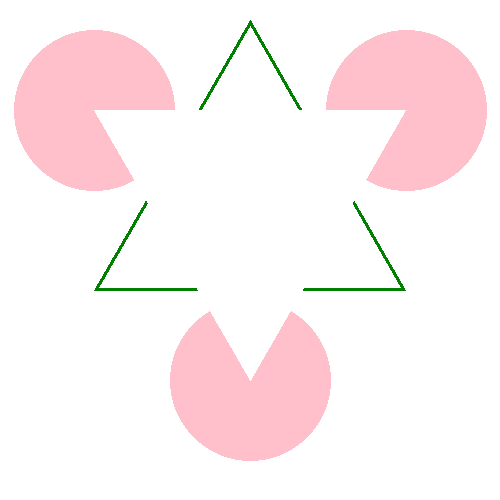

In [362]:
# drawing Kanizsa triangle

# some utilities
def rot2d(angle):
  return np.array([[np.cos(angle), -np.sin(angle)],
                   [np.sin(angle), np.cos(angle)]])
size = 500
center = np.array((size/2, size/2 * 4/5)) # some correction so the triangle fits
unit_x = np.array([1,0])

# actual drawing
img = Image.new("RGB", (size, size), "white")
draw = ImageDraw.Draw(img)

ref_circ_radius = 180
circ_radius = 80

omega_0 = np.pi/2
angles = [omega_0, omega_0 - 2/3 * np.pi, omega_0 - 4/3 * np.pi]
c0 = np.round((rot2d(angles[0]) @ unit_x) * ref_circ_radius + center).tolist()
c1 = np.round((rot2d(angles[1]) @ unit_x) * ref_circ_radius + center).tolist()
c2 = np.round((rot2d(angles[2]) @ unit_x) * ref_circ_radius + center).tolist()

draw.circle(c0, radius=circ_radius, fill="pink")
draw.circle(c1, radius=circ_radius, fill="pink")
draw.circle(c2, radius=circ_radius, fill="pink")
draw.regular_polygon(
    bounding_circle=(center.tolist(), ref_circ_radius),
    n_sides=3,
    outline="green",
    width = 3,
    rotation=0
    )
draw.regular_polygon(
    bounding_circle=(center.tolist(), ref_circ_radius),
    n_sides=3,
    fill="white",
    rotation=180
    )

img.save("kanizsa.png")
img

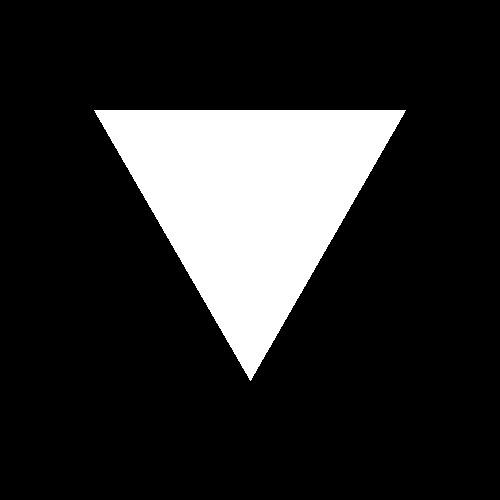

In [363]:
# drawing the mask of inpainting

img = Image.new("RGB", (size, size), "black")
draw = ImageDraw.Draw(img)

draw.regular_polygon(
    bounding_circle=(center.tolist(), ref_circ_radius),
    n_sides=3,
    fill="white",
    rotation=180
    )

img.save("kanizsa_mask.png")
img

bool (500, 500)


/tmp/ipython-input-3675389466.py:23: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  display(Image.fromarray(array, mode="LAB" if LAB else "RGB").convert("RGB"))


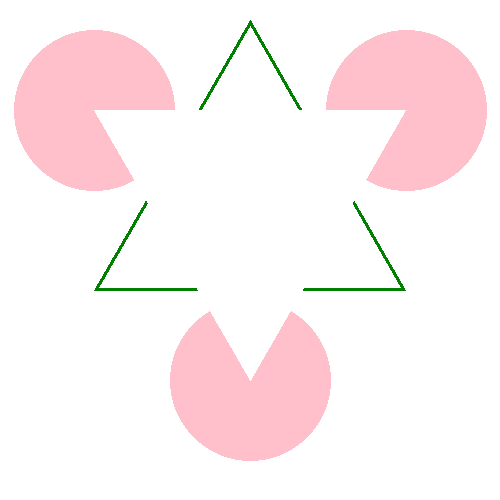

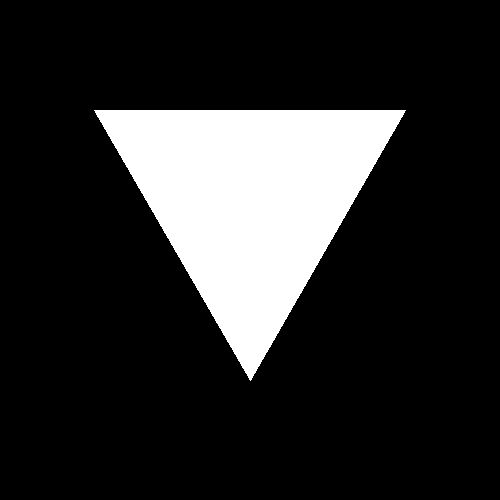

In [364]:
def read_image(path, *, mask=False, grayscale=False, LAB=False):
  "Open and parse image file as a numpy array to process"
  img = Image.open(path)
  if grayscale:
    img = img.convert("L")
    arr = np.array(img)
    return arr/arr.max()
  if mask:
    img = img.convert("1") # masks are just boolean arrays
    return np.array(img)
  if LAB:
    img = img.convert("LAB")
    return np.array(img)

  return np.array(img.convert("RGB"))

def display_img(array, LAB=False):
  if np.issubdtype(array.dtype,float) and len(array.shape) == 2:
    display(Image.fromarray(255 * array / array.max()).convert("L"))
  elif np.issubdtype(array.dtype,bool) and len(array.shape) == 2:
    display(Image.fromarray(array))
  else:
    display(Image.fromarray(array, mode="LAB" if LAB else "RGB").convert("RGB"))

img = read_image("kanizsa.png")
img_gray = read_image("kanizsa.png", grayscale=True)
img_lab = read_image("kanizsa.png", LAB=True)
mask = read_image("kanizsa_mask.png", mask = True)
print(mask.dtype, mask.shape)

display_img(img)
display_img(mask)

In [365]:
target_mask = mask # Omega
target_mask_num = target_mask.astype(np.int8)
source_mask = ~ mask # Phi = I - Omega

In [366]:
def pad_image(img, pad_size):
  """creates a padded image by repeating the margins"""
  # the corner will just be the corner pixel as a square
  def gen_corner_pad(value):
    return np.full(
        shape=(pad_size, pad_size, *img.shape[2:]),
        fill_value = value,
        dtype = img.dtype,
    )

  #pad above

  # this line needs some shape casting to keep the array bidimensional
  # that is shape == (1, width) rathern than shape == (width, )
  upper_row = img[0,:].reshape((1,*img.shape[1:]))

  above_pad = np.repeat(upper_row, pad_size, axis=0)
  new_img = np.vstack([above_pad, img])

  # pad left

  corner_pad = gen_corner_pad(img[0,0])

  left_column = img[:,0].reshape((img.shape[0], 1, *img.shape[2:]))
  left_pad = np.repeat(left_column, pad_size, axis=1)

  left_pad = np.vstack([corner_pad, left_pad])

  new_img = np.hstack([left_pad, new_img])

  # pad right

  corner_pad = gen_corner_pad(img[0,-1])
  right_column = img[:,-1].reshape((img.shape[0], 1, *img.shape[2:]))
  right_pad = np.repeat(right_column, pad_size, axis=1)
  right_pad = np.vstack([corner_pad, right_pad])

  new_img = np.hstack([new_img, right_pad])

  # pad bottom

  bottom_row = img[-1,:].reshape((1, *img.shape[1:]))
  bottom_pad = np.repeat(bottom_row, pad_size, axis=0)

  bottom_pad = np.hstack([gen_corner_pad(img[-1,0]),
                          bottom_pad,
                          gen_corner_pad(img[-1,-1])])

  new_img = np.vstack([new_img, bottom_pad])

  return new_img


def convolve(img, ker):
  m = ker.shape[0]
  assert ker.shape[1] == m and len(ker.shape) == 2, "kernel must be square"

  pad_size = int(m//2)
  padded_img = pad_image(img, pad_size)
  windows = sliding_window_view(padded_img, (*ker.shape,*img.shape[2:]))
  convolved = np.nansum(windows * ker[np.newaxis, np.newaxis, :],axis=(2,3))
  return convolved

In [367]:
# sobel gradient
def sobel_grad(img):
  sobel_x = np.array([[-1, 0, +1],
                      [-2, 0, +2],
                      [-1, 0, +1]])
  sobel_y = sobel_x.T

  dx = convolve(img, sobel_x)
  dy = convolve(img, sobel_y)
  grad = np.stack([dx,dy], axis=2)
  return grad

In [368]:
def naive_grad(img):
  kerx =np.array([[ 0, 0, 0],
                  [-1, 0, 1],
                  [ 0, 0, 0]])

  kery =np.array([[ 0, -1, 0],
                  [ 0, 0, 0],
                  [ 0,1, 0]])

  return np.stack( [convolve(img,kerx),  convolve(img,kery)], axis=2 )


In [389]:
def plot_grad(img, grad, LAB=False, sample=1):
  grad_norm = np.linalg.norm(grad, axis=2)
  grad_unit = np.divide(grad,grad_norm[:,:,np.newaxis], where= grad_norm[:,:,np.newaxis] > 0)


  dx, dy = grad_unit[:,:,0], grad_unit[:,:,1]
  indices = np.nonzero(grad_norm)
  chosen_indices = np.random.uniform(size=len(indices[0])) < sample # too many values, lets just sample
  indices = (indices[0][chosen_indices], indices[1][chosen_indices])


  fig, ax = plt.subplots()
  ax.set_xlim(0,target_mask_num.shape[0])
  ax.set_ylim(0,target_mask_num.shape[1])
  #ax.invert_yaxis()
  if LAB:
    # parse as LAB
    img = Image.fromarray(img, mode="LAB").convert("RGB")

  ax.imshow(img)
  ax.quiver(indices[1],indices[0],dx[indices], dy[indices], color="red", scale=10)


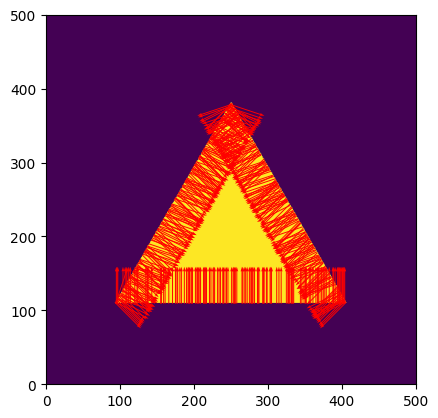

In [383]:
grad = sobel_grad(target_mask_num)
grad = source_mask[:,:, np.newaxis] * grad # keep only gradients inside the mask

plot_grad(target_mask, grad)

In [384]:

x_i,y_i = [110,94+80] # end of first pacman mouth
texel_slice = [slice(x_i-texel_rad,x_i+texel_rad+1),slice(y_i-texel_rad,y_i+texel_rad+1)]

print("--- target_mask")
display((target_mask[*texel_slice]))
print("--- sobel_grad_x")
display(np.round(grad[*texel_slice,0],2))
print("--- sobel_grad_y")
display(np.round(grad[*texel_slice,1],2))

--- target_mask


array([[False, False, False, False, False, False, False, False, False],
       [False, False, False, False, False, False, False, False, False],
       [False, False, False, False, False, False, False, False, False],
       [False, False, False, False, False, False, False, False, False],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True]])

--- sobel_grad_x


array([[0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0]])

--- sobel_grad_y


array([[0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0],
       [4, 4, 4, 4, 4, 4, 4, 4, 4],
       [0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0]])

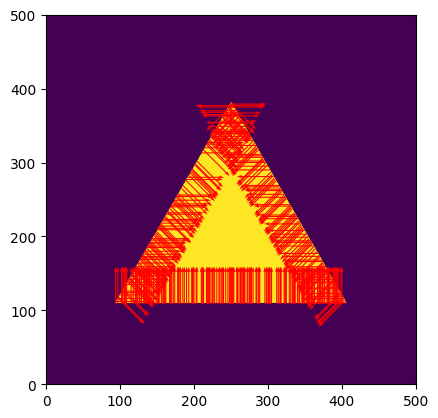

In [372]:

grad = naive_grad(target_mask_num)
grad = grad * source_mask[:,:,np.newaxis] # keep only gradients inside the mask


plot_grad(target_mask, grad)


/tmp/ipython-input-3675389466.py:23: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  display(Image.fromarray(array, mode="LAB" if LAB else "RGB").convert("RGB"))


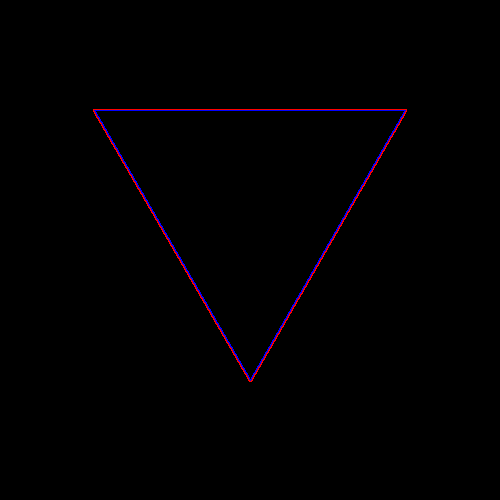

In [385]:
grad = sobel_grad(target_mask_num)
border_in_source = np.linalg.norm(source_mask[:,:, np.newaxis] * grad, axis=2) > 0
border_in_target = np.linalg.norm(target_mask[:,:, np.newaxis] * grad, axis=2) > 0

plain = np.zeros_like(img)
plain[border_in_source] = np.array([255,0,0])
plain[border_in_target] = np.array([0,0,255])
display_img(plain)


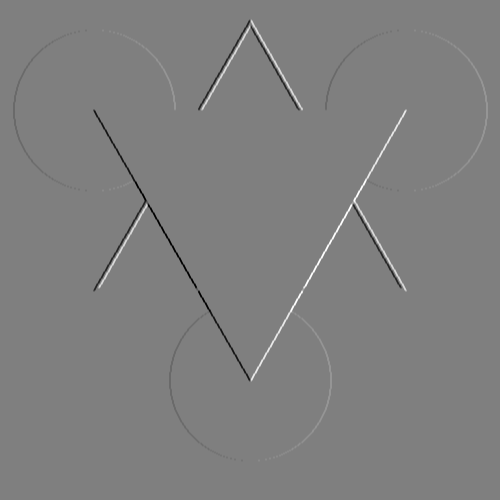

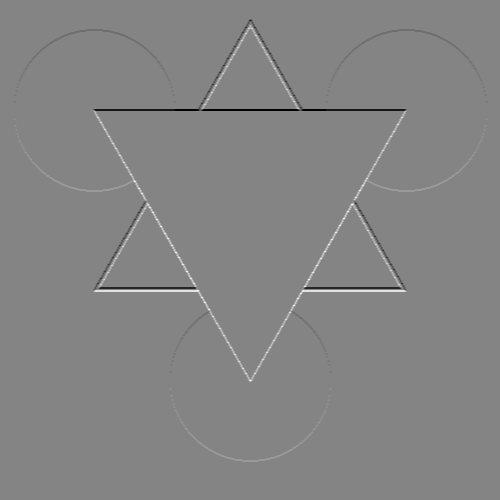

In [463]:
# reference image for gradient
def image_gradient(img_gray, target_mask):
  grad_img = img_gray.copy()
  grad_img[target_mask] = np.nan

  grad = sobel_grad(grad_img)
  return grad

grad = image_gradient(img_gray, target_mask)
grad_norm = np.linalg.norm(grad,axis=2)


normalized_grad_x = grad[:,:,0] / np.abs(grad).max()
normalized_grad_x = 0.5 + 0.5 * normalized_grad_x
display_img(normalized_grad_x)

normalized_grad_y = grad[:,:,1] / np.abs(grad).max()
normalized_grad_y = 0.5 + 0.5 * normalized_grad_y
display_img(normalized_grad_y)

/tmp/ipython-input-1597464534.py:17: RuntimeWarning: Mean of empty slice
  border_grad_x = np.nanmean(windows_x, where=border_in_source[:,:,np.newaxis,np.newaxis], axis=(2,3))
/tmp/ipython-input-1597464534.py:19: RuntimeWarning: Mean of empty slice
  border_grad_y = np.nanmean(windows_y, where=border_in_source[:,:,np.newaxis,np.newaxis], axis=(2,3))
/tmp/ipython-input-3675389466.py:23: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  display(Image.fromarray(array, mode="LAB" if LAB else "RGB").convert("RGB"))


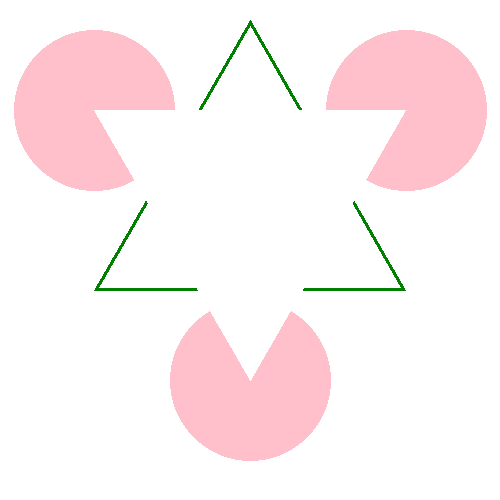

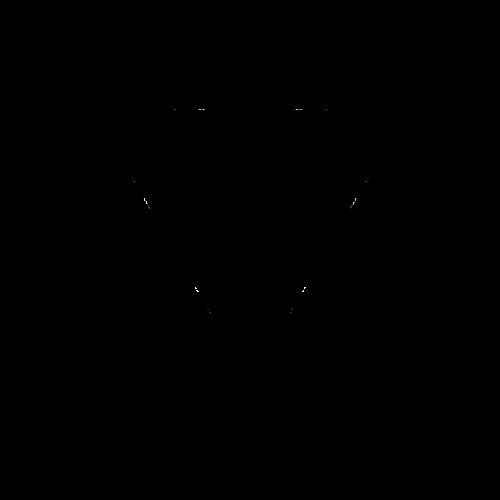

In [465]:

def contour_grad(texel_side,image_grad, target_mask, source_mask, border_in_source):
  "Returns the contour gradient along the border on the source side"
  texel_rad = int(texel_side//2)


  nan_target = np.zeros_like(image_grad)
  nan_target[target_mask] = np.nan
  nan_target[border_in_source] = np.nan # also do not account for the border pixels (false gradients)
  grad_with_nans = image_grad * source_mask[:,:,np.newaxis] + nan_target

  grad_padded_with_nans = pad_image(grad_with_nans, texel_rad)
  # we will use column windows for x and row windows for y
  windows_x = sliding_window_view(grad_padded_with_nans[:,texel_rad:-texel_rad,0], window_shape=(texel_side,1))
  windows_y = sliding_window_view(grad_padded_with_nans[texel_rad:-texel_rad,:,1], window_shape=(1,texel_side))


  border_grad_x = np.nanmean(windows_x, where=border_in_source[:,:,np.newaxis,np.newaxis], axis=(2,3))
  border_grad_x = np.nan_to_num(border_grad_x, nan=0)
  border_grad_y = np.nanmean(windows_y, where=border_in_source[:,:,np.newaxis,np.newaxis], axis=(2,3))
  border_grad_y = np.nan_to_num(border_grad_y, nan=0)

  border_in_source_grad = np.stack([border_grad_x, border_grad_y], axis=-1)
  return border_in_source_grad
#img_res_x = res_x / np.nanmax(res_x)
#display_img(np.nan_to_num(img_res_x))


texel_side = 9
border_in_source_grad = contour_grad(
    texel_side=texel_side,
    image_grad = image_gradient(img_gray, target_mask),
    target_mask = target_mask,
    source_mask = source_mask,
    border_in_source = border_in_source,
    )
#plot_grad(img,border_in_source_grad)
test = np.linalg.norm(border_in_source_grad, axis=2)
display_img(img)
display_img(test / test.max())

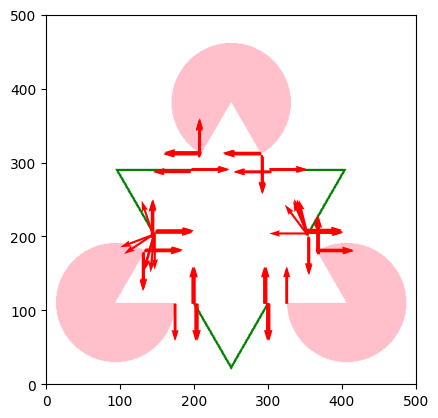

In [390]:
plot_grad(img, border_in_source_grad @ rot2d(np.pi/2))

In [378]:

#x_i,y_i = [110,94+80] # end of first pacman mouth
x_i,y_i = [110,94] # center of first pacman mouth
texel_slice = [slice(x_i-texel_rad,x_i+texel_rad+1),slice(y_i-texel_rad,y_i+texel_rad+1)]

print("--- Img Gray")
display(np.round(img_gray[*texel_slice],2))
print("--- grad img")
display(np.round(grad_img[*texel_slice],2))
print("--- Border")
display(border_in_source[*texel_slice])
print("--- Grad with nans x: ")
display(np.round(grad_with_nans[*texel_slice,0],2))
print("--- Windows grads x")
display(np.round(windows_x[x_i,y_i],2))
print("--- border grad x")
display(np.round(border_grad_x[*texel_slice], 2))
print("--- Grad with nans y: ")
display(np.round(grad_with_nans[*texel_slice,1],2))
print("--- Windows grads y")
display(np.round(windows_y[x_i,y_i],2))
print("--- border grad y")
display(np.round(border_grad_y[*texel_slice], 2))

--- Img Gray


array([[0.83, 0.83, 0.83, 0.83, 0.83, 0.83, 0.83, 0.83, 0.83],
       [0.83, 0.83, 0.83, 0.83, 0.83, 0.83, 0.83, 0.83, 0.83],
       [0.83, 0.83, 0.83, 0.83, 0.83, 0.83, 0.83, 0.83, 0.83],
       [0.83, 0.83, 0.83, 0.83, 0.83, 0.83, 0.83, 0.83, 0.83],
       [0.83, 0.83, 0.83, 0.83, 1.  , 1.  , 1.  , 1.  , 1.  ],
       [0.83, 0.83, 0.83, 0.83, 0.83, 1.  , 1.  , 1.  , 1.  ],
       [0.83, 0.83, 0.83, 0.83, 0.83, 1.  , 1.  , 1.  , 1.  ],
       [0.83, 0.83, 0.83, 0.83, 0.83, 0.83, 1.  , 1.  , 1.  ],
       [0.83, 0.83, 0.83, 0.83, 0.83, 0.83, 1.  , 1.  , 1.  ]])

--- grad img


array([[0.83, 0.83, 0.83, 0.83, 0.83, 0.83, 0.83, 0.83, 0.83],
       [0.83, 0.83, 0.83, 0.83, 0.83, 0.83, 0.83, 0.83, 0.83],
       [0.83, 0.83, 0.83, 0.83, 0.83, 0.83, 0.83, 0.83, 0.83],
       [0.83, 0.83, 0.83, 0.83, 0.83, 0.83, 0.83, 0.83, 0.83],
       [0.83, 0.83, 0.83, 0.83,  nan,  nan,  nan,  nan,  nan],
       [0.83, 0.83, 0.83, 0.83, 0.83,  nan,  nan,  nan,  nan],
       [0.83, 0.83, 0.83, 0.83, 0.83,  nan,  nan,  nan,  nan],
       [0.83, 0.83, 0.83, 0.83, 0.83, 0.83,  nan,  nan,  nan],
       [0.83, 0.83, 0.83, 0.83, 0.83, 0.83,  nan,  nan,  nan]])

--- Border


...

array([[ 0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ],
       [ 0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ],
       [ 0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ],
       [ 0.  ,  0.  ,  0.  , -0.83,   nan,   nan,   nan,   nan,   nan],
       [ 0.  ,  0.  ,  0.  ,   nan,   nan,   nan,   nan,   nan,   nan],
       [ 0.  ,  0.  ,  0.  ,  0.83,   nan,   nan,   nan,   nan,   nan],
       [ 0.  ,  0.  ,  0.  ,  0.  ,   nan,   nan,   nan,   nan,   nan],
       [ 0.  ,  0.  ,  0.  ,  0.  ,  0.83,   nan,   nan,   nan,   nan],
       [ 0.  ,  0.  ,  0.  ,  0.  ,  0.  ,   nan,   nan,   nan,   nan]])

--- Windows grads y


array([[ 0.,  0.,  0., nan, nan, nan, nan, nan, nan]])

--- border grad y


array([[ 0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ],
       [ 0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ],
       [ 0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ],
       [ 0.  ,  0.  ,  0.  ,  0.  , -0.21, -0.28, -0.42, -0.83,  0.  ],
       [ 0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ],
       [ 0.  ,  0.  ,  0.  ,  0.  ,  0.21,  0.  ,  0.  ,  0.  ,  0.  ],
       [ 0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ],
       [ 0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.21,  0.  ,  0.  ,  0.  ],
       [ 0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ]])

In [466]:
grad = sobel_grad(target_mask_num)
grad = source_mask[:,:, np.newaxis] * grad # keep only gradients inside the mask
contour_grad =  border_in_source[:,:, np.newaxis] * grad
contour_norms =  np.linalg.norm(contour_grad, axis=2)[:,:,np.newaxis]
contour_normals = np.divide(contour_grad,contour_norms, where=contour_norms > 0)

isophotes = border_in_source_grad @ rot2d(np.pi/2)

# change shapes so we can get the dotproduct
contour_normals_cols = contour_normals.reshape((*contour_normals.shape,1)) # column vectors
isophotes_rows = isophotes.reshape((*isophotes.shape[:2],1,2)) # row vectors
data_values = np.abs(isophotes_rows @ contour_normals_cols).reshape(img_gray.shape)

In [445]:
x_i,y_i = [199,109] # center of first pacman mouth
texel_slice = [slice(y_i-texel_rad,y_i+texel_rad+1),slice(x_i-texel_rad,x_i+texel_rad+1)]

print("--- img gray")
display(np.round(img_gray[*texel_slice],2))
print("--- target_mask")
display((target_mask_num[*texel_slice]))
print("--- contour normals 0th")
display(np.round(contour_normals[*texel_slice, 0],2))
print("--- contour normals 1th")
display(np.round(contour_normals[*texel_slice, 1],2))
print("--- isophote 0th")
display(np.round(isophotes[*texel_slice, 0],2))
print("--- isophote 1th")
display(np.round(isophotes[*texel_slice, 1],2))
print("--- data value")
display(np.round(data_values[*texel_slice],2))

--- img gray


array([[1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 0.29, 0.29, 0.29],
       [1.  , 1.  , 1.  , 1.  , 1.  , 0.29, 0.29, 0.29, 0.29],
       [1.  , 1.  , 1.  , 1.  , 1.  , 0.29, 0.29, 0.29, 1.  ],
       [1.  , 1.  , 1.  , 1.  , 0.29, 0.29, 0.29, 0.29, 1.  ],
       [1.  , 1.  , 1.  , 1.  , 0.29, 0.29, 0.29, 1.  , 1.  ],
       [1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  ],
       [1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  ],
       [1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  ],
       [1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  ]])

--- target_mask


array([[0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0],
       [1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1]], dtype=int8)

--- contour normals 0th


...

array([[ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0., -0., -0., -0., -0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.]])

--- isophote 1th


array([[ 0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ],
       [ 0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ],
       [ 0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ],
       [ 0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ],
       [ 0.  ,  0.  ,  0.  ,  0.71,  2.12,  2.12,  0.53, -1.41, -2.47],
       [ 0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ],
       [ 0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ],
       [ 0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ],
       [ 0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ]])

--- data value


array([[0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.71, 2.12, 2.12, 0.53, 1.41, 2.47],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ]])

(500, 500, 3)


/tmp/ipython-input-3675389466.py:23: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  display(Image.fromarray(array, mode="LAB" if LAB else "RGB").convert("RGB"))


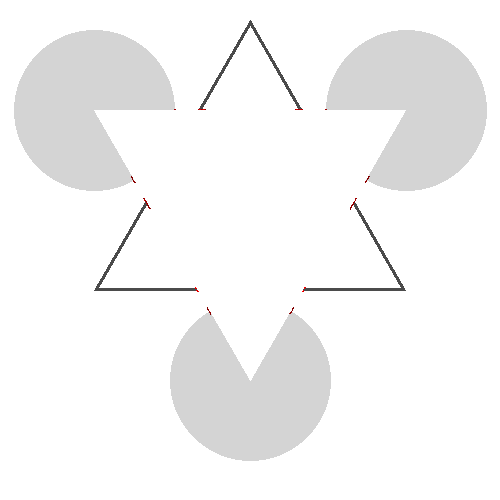

In [469]:
confidence = target_mask.astype(int)

test = data_values/ data_values.max()
test = test[:,:,np.newaxis] * np.array([128,0,0]) + np.array([127,0,0])
print(test.shape)
test = test.astype(np.uint8)

test_img = (img_gray[:,:,np.newaxis] * np.array([1,1,1]) * 255 ).astype(np.uint8)
test_img[data_values > 0] = test[data_values > 0]

display_img(test_img)
Image.fromarray(test_img).save("data_values_over_gray.png")